In [ ]:
import sys
from pathlib import Path

from bodge import Lattice
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [2]:
X, Y = 5, 5
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-6

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=None,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [3]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1000, verbose=False, temperature=T)

Converged after 1 iterations


In [4]:
ky_list = np.linspace(PI / 11, PI, 11)
print(ky_list)

[0.28559933 0.57119866 0.856798   1.14239733 1.42799666 1.71359599
 1.99919533 2.28479466 2.57039399 2.85599332 3.14159265]


In [5]:
free = H.free
print(free)

free = H.free_energy(temperature=T)
print(free)

-114.00101755582527
-114.00101755582526


In [6]:
X, Y = 25, 25
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-6

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

free = H.free_energy(temperature=T)
print(free)

-2890.673023494036


In [7]:
Free_arr = np.zeros(50)

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])
for i in range(25):
    F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.1,atol=1e-4, maxiter=1, temperature=T)
    Free_arr[i] = H.free

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.3, -0.3, 0.3j, -0.3j])
for i in range(25):
    F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.1,atol=1e-4, maxiter=1, temperature=T)
    Free_arr[49-i] = H.free

133.41036152640822


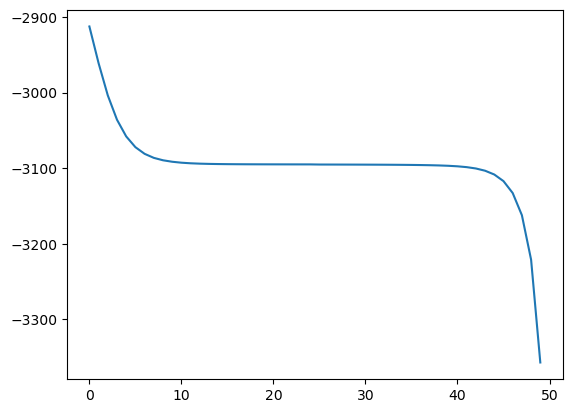

In [8]:
plt.plot(Free_arr)
print(H.free_energy_const_term())

In [9]:
free = H.free
print(free)

free = H.free_energy(T)
print(free)

F_xplus = np.mean(H.F_xplus)
F_xmin = np.mean(H.F_xmin)
F_yplus = np.mean(H.F_yplus)
F_ymin = np.mean(H.F_ymin)

print(F_xplus)
print(F_xmin)
print(F_yplus)
print(F_ymin)


-3095.0618734369145
-3095.0530637900292
(0.18022557853549676+0j)
(-0.18508453402375058+0j)
(0.008039747781593592+0.1919636259330689j)
(0.008039747781593592-0.1919636259330689j)
